In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

btc = pd.read_csv("../data/bitcoin_limpio.csv", parse_dates=["Date"])

# Columnas necesarias
btc["rendimiento_diario"] = btc["Close"].pct_change()
btc["volatilidad_30d"] = btc["rendimiento_diario"].rolling(30).std() * 100
btc["Año"] = btc["Date"].dt.year
btc["Mes"] = btc["Date"].dt.month

## 4.1 Evolución histórica del precio de Bitcoin

El siguiente gráfico muestra la evolución del precio de cierre diario 
de Bitcoin desde 2015 hasta la actualidad. Permite identificar visualmente 
los ciclos de crecimiento, los máximos históricos y las caídas más significativas 
a lo largo del tiempo.

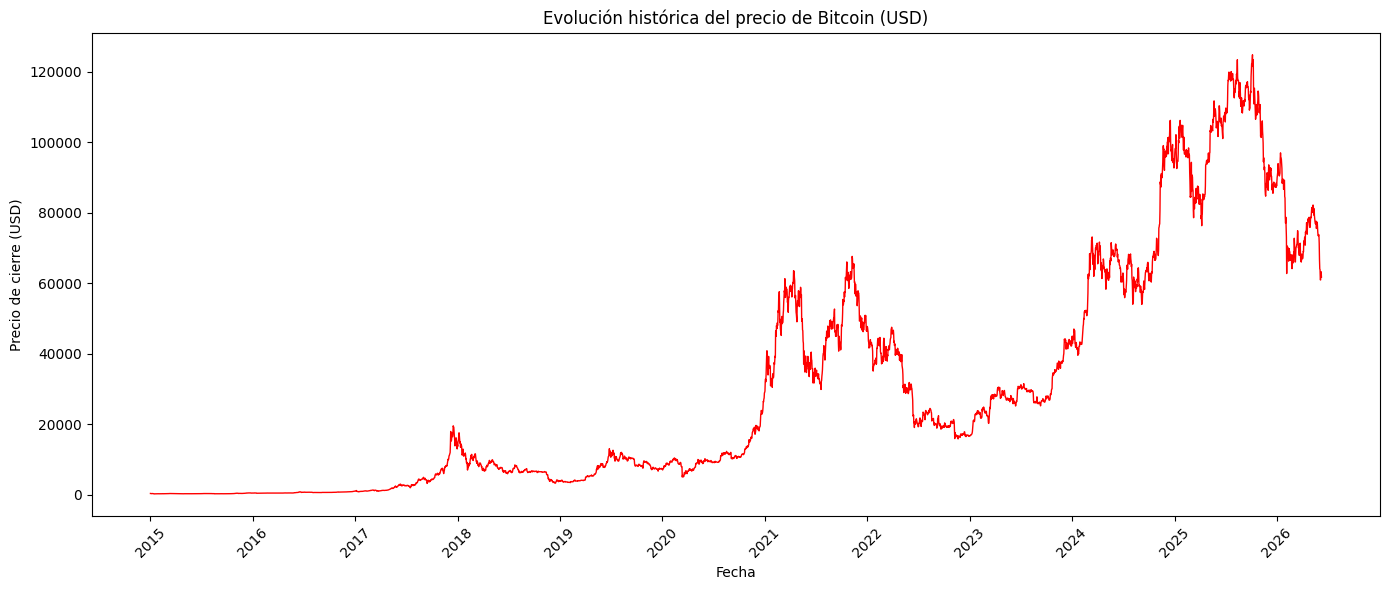

In [7]:
plt.figure(figsize=(14, 6))
plt.plot(btc["Date"], btc["Close"], color="red", linewidth=1)
plt.title("Evolución histórica del precio de Bitcoin (USD)")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre (USD)")
plt.xticks(pd.date_range(start="2015-01-01", end="2026-01-01", freq="YS"), 
           labels=range(2015, 2027), rotation=45)
plt.tight_layout()
plt.show()

#### Conclusión
Se observa que el precio de Bitcoin experimentó un crecimiento significativo 
desde 2015, con períodos de alta volatilidad y ciclos claros de auge y caída. 
Se identifican tres picos principales: 2017 con casi $20.000, 2021 con $65.000, 
y 2024-2025 donde se alcanzó el máximo histórico superando los $120.000, 
seguidos en todos los casos de correcciones importantes.

Este gráfico refleja la naturaleza cíclica del mercado de Bitcoin y la 
importancia de analizar los patrones históricos para comprender su comportamiento.

## 4.2 Períodos de mayor volatilidad

El siguiente gráfico muestra la volatilidad de Bitcoin a lo largo del tiempo,
calculada como la desviación estándar de los rendimientos diarios en una 
ventana móvil de 30 días. Los picos en la línea indican períodos donde 
el mercado tuvo movimientos más bruscos e impredecibles.

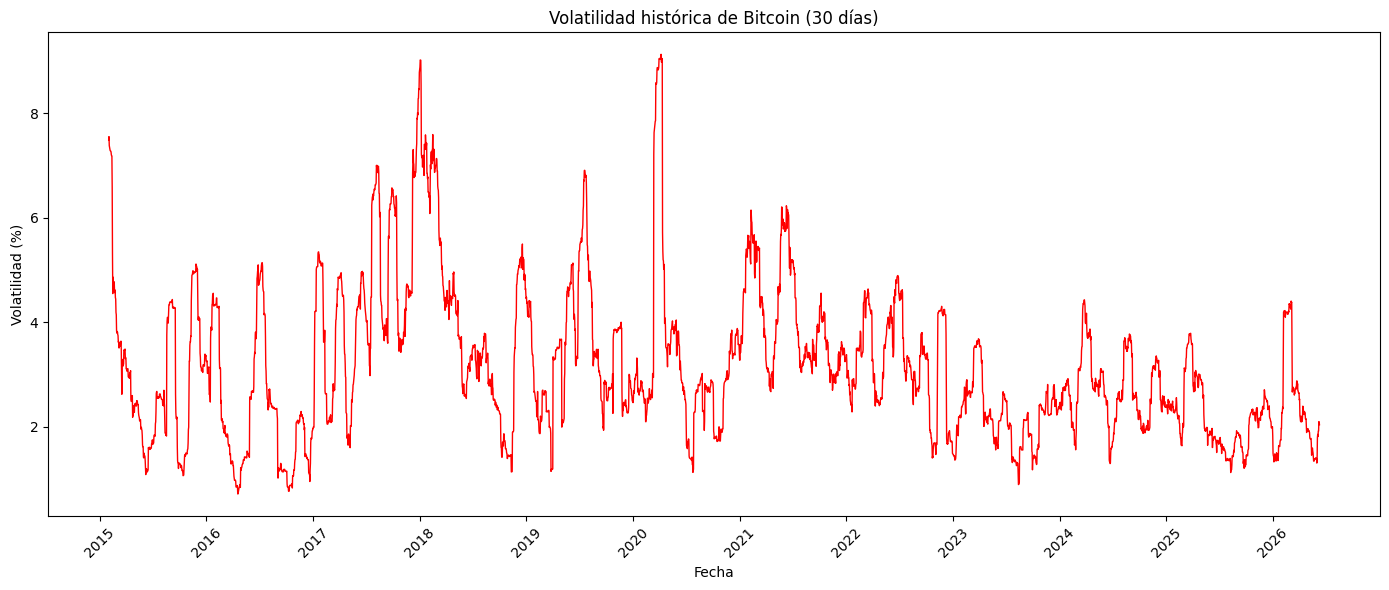

In [8]:
plt.figure(figsize=(14, 6))
plt.plot(btc["Date"], btc["volatilidad_30d"], color="red", linewidth=1)
plt.title("Volatilidad histórica de Bitcoin (30 días)")
plt.xlabel("Fecha")
plt.ylabel("Volatilidad (%)")
plt.xticks(pd.date_range(start="2015-01-01", end="2026-01-01", freq="YS"), 
           labels=range(2015, 2027), rotation=45)
plt.tight_layout()
plt.show()

#### Conclusión
El gráfico muestra claramente los principales períodos de turbulencia 
en el mercado de Bitcoin:

- **2015**: volatilidad alta inicial debido a que era un mercado nuevo 
  con pocos participantes y baja liquidez.
- **2018**: el pico más alto del gráfico, coincidiendo con el crash 
  posterior a la burbuja especulativa de 2017.
- **2020**: pico abrupto en marzo, coincidiendo con el crash global 
  provocado por el inicio de la pandemia de COVID-19.
- **2021**: volatilidad elevada durante todo el año, acompañando 
  el fuerte crecimiento del precio.

A partir de 2023 la volatilidad se mantiene más baja y estable, 
lo que sugiere una mayor maduración del mercado de Bitcoin.

## 4.3 Rendimiento anual de Bitcoin

El siguiente gráfico muestra el rendimiento anual de Bitcoin expresado 
en porcentaje, comparando el precio de cierre del primer y último día 
de cada año. Las barras verdes indican años con rendimiento positivo 
y las barras rojas años con rendimiento negativo.

**Calculamos el rendimiento anual para luego podes graficar**

In [11]:
rendimiento_anual = btc.groupby("Año")["Close"].agg(
    inicio="first", fin="last"
)

rendimiento_anual["rendimiento"] = ((rendimiento_anual["fin"] - rendimiento_anual["inicio"]) / rendimiento_anual["inicio"] * 100).round(2)

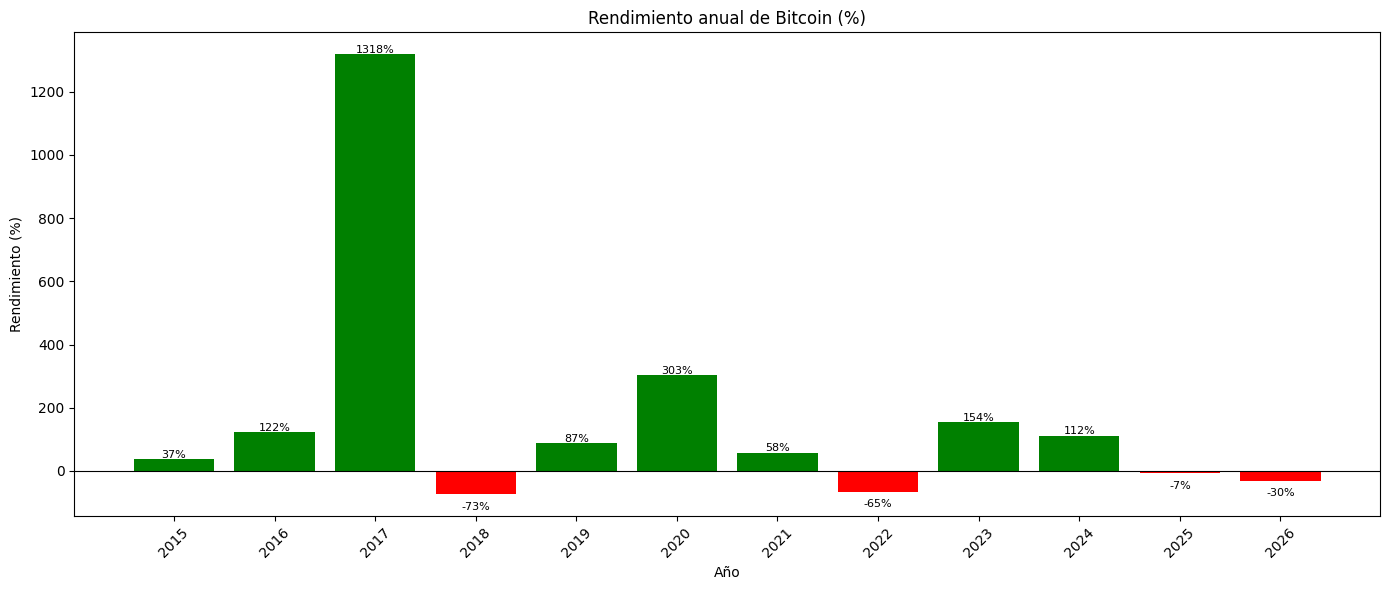

In [ ]:
colores = ['green' if x > 0 else 'red' for x in rendimiento_anual['rendimiento']]

plt.figure(figsize=(14, 6))
plt.bar(rendimiento_anual.index, rendimiento_anual['rendimiento'], color=colores)
plt.title("Rendimiento anual de Bitcoin (%)")
plt.xlabel("Año")
plt.ylabel("Rendimiento (%)")
plt.axhline(y=0, color='black', linewidth=0.8)
plt.xticks(rendimiento_anual.index, rotation=45)
for i, (year, row) in enumerate(rendimiento_anual.iterrows()):
    plt.text(year, row['rendimiento'] + (5 if row['rendimiento'] > 0 else -50), 
             f"{row['rendimiento']:.0f}%", 
             ha='center', fontsize=8)
plt.tight_layout()
plt.show()

#### Conclusión
El gráfico muestra que predominan las barras verdes, lo que indica que 
la mayoría de los años Bitcoin tuvo un rendimiento anual positivo.

Se destaca el año 2017 con un rendimiento extraordinario del 1318%, 
visible como la barra más alta del gráfico. Sin embargo al año siguiente, 
2018 registró la mayor caída con un -73%, reflejando visualmente 
el patrón cíclico que caracteriza al mercado de Bitcoin.

## 4.4 Relación entre volumen de operaciones y movimiento del precio

El siguiente gráfico combina dos variables en un mismo eje: el volumen 
operado promedio por año representado en barras, y el precio de cierre 
promedio por año representado en una línea. El objetivo es identificar 
visualmente si existe alguna relación entre la actividad del mercado 
y el movimiento del precio.

**Calculamos volumen promedio y precio promedio por año para poder usarlo en la grafica**

In [15]:
volumen_anual = btc.groupby('Año')['Volume'].mean()
precio_anual = btc.groupby("Año")['Close'].mean()

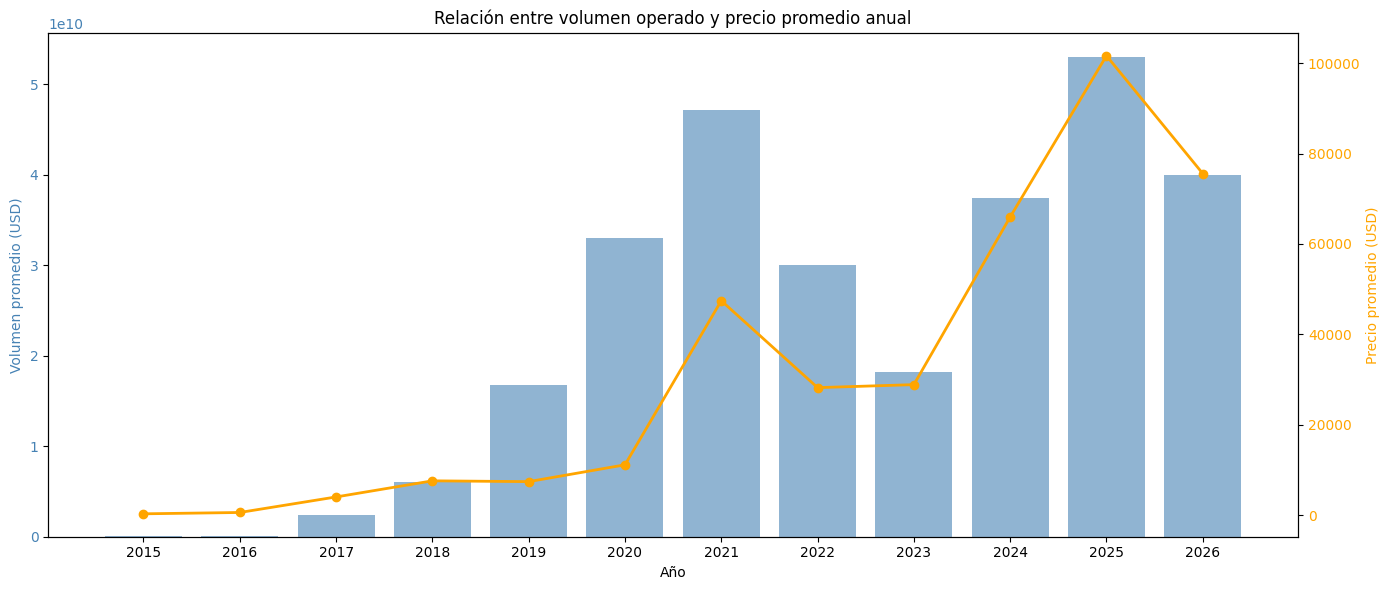

In [16]:

fig, ax1 = plt.subplots(figsize=(14, 6))


ax1.bar(volumen_anual.index, volumen_anual.values, color='steelblue', alpha=0.6, label='Volumen')
ax1.set_xlabel('Año')
ax1.set_ylabel('Volumen promedio (USD)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(volumen_anual.index)


ax2 = ax1.twinx()
ax2.plot(precio_anual.index, precio_anual.values, color='orange', linewidth=2, marker='o', label='Precio')
ax2.set_ylabel('Precio promedio (USD)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Relación entre volumen operado y precio promedio anual')
plt.tight_layout()
plt.show()

#### Conclusión
En los primeros años (2015-2018) tanto el volumen como el precio eran 
muy bajos y crecieron de forma conjunta. A partir de 2019 el volumen 
comenzó a crecer considerablemente mientras el precio se mantuvo relativamente 
estable, lo que marcó el inicio de una divergencia entre ambas variables.

Desde 2020 en adelante el volumen creció de forma sostenida, mientras 
el precio lo hizo de manera más progresiva. En 2022 y 2023 ambas variables 
bajaron poniéndose nuevamente a la par, para luego crecer fuertemente 
hasta 2025, donde se registraron simultáneamente el precio promedio 
más alto y el volumen más alto de toda la serie histórica.

Esto confirma lo calculado en el EDA, donde la correlación entre volumen 
y rendimiento diario fue de -0.02, indicando que el volumen no es 
un predictor directo del movimiento del precio.

## 4.5 Volatilidad promedio por mes

El siguiente gráfico muestra la volatilidad promedio histórica de Bitcoin 
para cada mes del año, calculada sobre todos los años disponibles desde 
2015 hasta la actualidad. El objetivo es identificar si existen patrones 
estacionales, es decir si hay meses que históricamente tendieron a ser 
más volátiles o más estables que otros.


**Calculamos la volatilidad promedio por mes para despues utilizarla en el grafico**

In [21]:
volatilidad_mensual = btc.groupby('Mes')['volatilidad_30d'].mean()

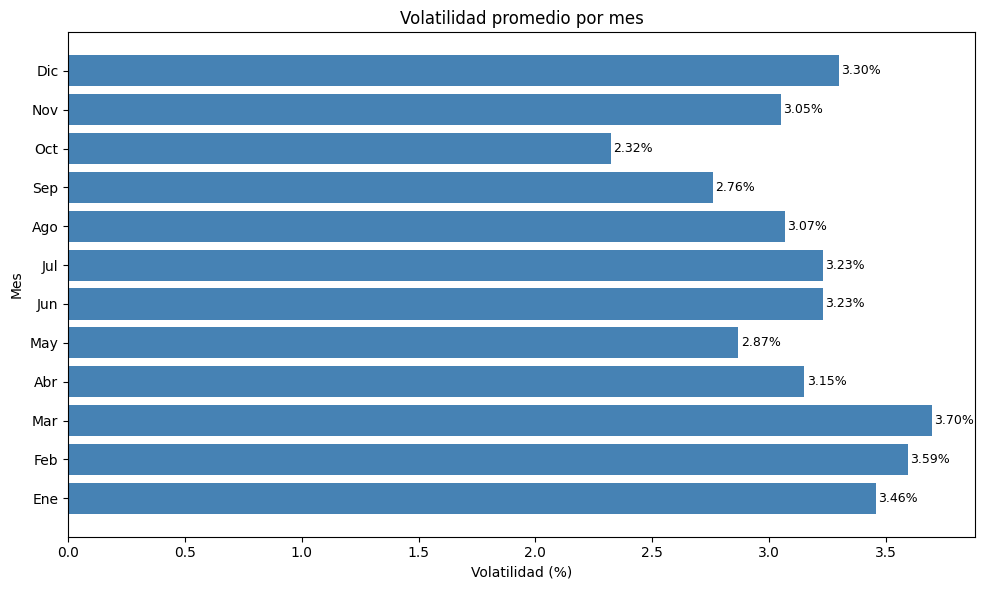

In [22]:
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
         'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

plt.figure(figsize=(10, 6))
plt.barh(meses, volatilidad_mensual.values, color='steelblue')
plt.title('Volatilidad promedio por mes')
plt.xlabel('Volatilidad (%)')
plt.ylabel('Mes')
for i, valor in enumerate(volatilidad_mensual.values):
    plt.text(valor + 0.01, i, f"{valor:.2f}%", va='center', fontsize=9)
plt.tight_layout()
plt.show()

#### Conclusión
El gráfico confirma visualmente lo analizado en el EDA. Octubre presenta 
la barra más corta con un 2.32% de volatilidad, siendo el mes más estable 
históricamente. Por el contrario, marzo tiene la barra más extensa con 
un 3.70%, siendo el mes más volátil.

Se puede observar claramente que los primeros meses del año (enero, febrero 
y marzo) concentran las barras más largas, mientras que el segundo semestre 
(agosto, septiembre y octubre) presenta mayor estabilidad con barras 
notablemente más cortas.